<a href="https://colab.research.google.com/github/Abdulwadud4/ACCESS-6.0-Data-Science-track/blob/main/capstone_project_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
isr = pd.read_csv("/content/insurance.csv")

In [3]:
#loading and inspecting the dataset
isr.tail(10)

,age,sex,bmi,children,smoker,region,charges
1328,23,female,24.225,2,no,northeast,22395.74424
1329,52,male,38.600,2,no,southwest,10325.20600
1330,57,female,25.740,2,no,southeast,12629.16560
1331,23,female,33.400,0,no,southwest,10795.93733
1332,52,female,44.700,3,no,southwest,11411.68500
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500
1337,61,female,29.070,0,yes,northwest,29141.36030


In [4]:
isr.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [5]:
isr.info(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
isr.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
isr.columns[isr.isna().any()]

Index([], dtype='object')

In [8]:
isr.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [9]:
print(f"Column names: {isr.columns.to_list()}")
print(f"Full size of dataset (rows and columns): {isr.shape}")

Column names: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']
Full size of dataset (rows and columns): (1338, 7)


In [10]:
#selecting any two numerical column
isr[['age', 'bmi', 'children', 'charges']].head(10)

,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520
5,31,25.740,0,3756.62160
6,46,33.440,1,8240.58960
7,37,27.740,3,7281.50560
8,37,29.830,2,6406.41070
9,60,25.840,0,28923.13692


In [11]:
#filtering the rows using a condition of my choice
isr[isr['children'] > 3].head(10)

,age,sex,bmi,children,smoker,region,charges
32,19,female,28.600,5,no,southwest,4687.79700
61,25,male,33.660,4,no,southeast,4504.66240
71,31,male,28.500,5,no,northeast,6799.45800
83,48,female,41.230,4,no,northwest,11033.66170
165,47,male,28.215,4,no,northeast,10407.08585
166,20,female,37.000,5,no,southwest,4830.63000
211,40,male,30.875,4,no,northwest,8162.71625
258,51,male,24.415,4,no,northwest,11520.09985
321,26,female,29.640,4,no,northeast,24671.66334
344,49,female,41.470,4,no,southeast,10977.20630


In [12]:
isr.loc[isr['age'] > 18, ['sex', 'smoker']].head(10)

,sex,smoker
0,female,yes
2,male,no
3,male,no
4,male,no
5,female,no
6,female,no
7,female,no
8,male,no
9,female,no
10,male,no


In [13]:
isr.loc[isr['age'] > 18, ['sex', 'smoker']].tail(10)

,sex,smoker
1326,female,no
1327,male,no
1328,female,no
1329,male,no
1330,female,no
1331,female,no
1332,female,no
1333,male,no
1336,female,no
1337,female,yes


In [14]:
isr.duplicated().sum()

np.int64(1)

In [15]:
isr.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
1333,False
1334,False
1335,False
1336,False


In [16]:
# Remove duplicate rows
isr = isr.drop_duplicates()


print(f"Shape after removing duplicates: {isr.shape}")


Shape after removing duplicates: (1337, 7)


In [17]:
#aggregation multiple metrics
isr.groupby('sex').agg({'charges': ['sum', 'mean', 'max', 'count']})

charges                                 
                 sum          mean          max count
sex                                                  
female  8.321061e+06  12569.578844  63770.42801   662
male    9.433124e+06  13974.998864  62592.87309   675

In [18]:
#this means we have more males paying medical insurance than the females

In [19]:
#aggregation multiple metrics
isr.groupby('smoker').agg({'charges': ['sum', 'mean', 'max', 'count']})

charges                                 
                 sum          mean          max count
smoker                                               
no      8.972422e+06   8440.660307  36910.60803  1063
yes     8.781764e+06  32050.231832  63770.42801   274

In [20]:
#we have higher number of people that are not smoking paying medical insurance

In [21]:
#aggregation multiple metrics
isr.groupby('age').agg({'charges': ['sum', 'mean', 'max', 'count']})

charges                                 
               sum          mean          max count
age                                                
18   488949.011389   7086.217556  38792.68560    69
19   661218.271650   9868.929428  39722.74620    67
20   294631.234350  10159.697736  38344.56600    29
21   132453.001230   4730.464330  26018.95052    28
22   280362.118450  10012.932802  44501.39820    28
23   347754.961110  12419.820040  40904.19950    28
24   298144.446940  10648.015962  38126.24650    28
25   275474.228700   9838.365311  42112.23560    28
26   171747.108640   6133.825309  36085.21900    28
27   341171.648200  12184.701721  39611.75770    28
28   253937.251800   9069.187564  51194.55914    28
29   281614.285630  10430.158727  44585.45587    27
30   343415.979670  12719.110358  40932.42950    27
31   275318.475480  10196.980573  58571.07448    27
32   239727.807560   9220.300291  37607.52770    26
33   321139.857670  12351.532987  55135.40209    26
34   301951.731140  11613.528121  43943.87610    26
35   282679.550780  11307.182031  39983.42595    25
36   305111.903450  12204.476138  43753.33705    25
37   450497.796930  18019.911877  46113.51100    25
38   202568.341850   8102.733674  41949.24410    25
39   294456.073630  11778.242945  40103.89000    25
40   317850.785370  11772.251310  40003.33225    27
41   260651.132540   9653.745650  40273.64550    27
42   352648.044060  13061.038669  43896.37630    27
43   520216.523640  19267.278653  45863.20500    27
44   428203.707850  15859.396587  48885.13561    27
45   430075.795830  14830.199856  62592.87309    29
46   415935.128520  14342.590639  46151.12450    29
47   511965.988200  17653.999593  44202.65360    29
48   424342.512910  14632.500445  45702.02235    29
49   355488.175400  12696.006264  39727.61400    28
50   454227.095720  15663.003301  42856.83800    29
51   454785.420150  15682.255867  47462.89400    29
52   529431.821860  18256.269719  60021.39897    29
53   448586.061140  16020.930755  46661.44240    28
54   525239.301310  18758.546475  63770.42801    28
55   420278.182700  16164.545488  44423.80300    26
56   390663.411750  15025.515837  43921.18370    26
57   427626.816500  16447.185250  48675.51770    26
58   346973.202790  13878.928112  47496.49445    25
59   472396.738290  18895.869532  48970.24760    25
60   505526.625670  21979.418507  52590.82939    23
61   506562.525000  22024.457609  48517.56315    23
62   440768.701190  19163.856573  46718.16325    23
63   457354.964600  19884.998461  48824.45000    23
64   512061.678420  23275.530837  49577.66240    22

In [22]:
#checking the frequency of values in the children column
isr["children"].value_counts()

,count
children,
0,573
1,324
2,240
3,157
4,25
5,18


In [23]:
#checking the frequency of values in the bmi column
isr["bmi"].value_counts()

,count
bmi,
32.300,13
28.310,9
30.800,8
31.350,8
30.495,8
...,...
39.425,1
40.480,1
38.900,1


In [24]:
isr["age"].value_counts()

,count
age,
18,69
19,67
46,29
52,29
50,29
47,29
48,29
51,29
45,29


In [25]:
isr.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [26]:
#according to this, there isnt negative input

In [27]:
#checking if we have no missing values
for col in isr.columns:
  if isr[col].isna().sum() > 0:
    print(f"{col}: {isr[col].isna().sum()} - {isr[col].dtype}")
  else:
    print(f"{col} has no missing values")

age has no missing values
sex has no missing values
bmi has no missing values
children has no missing values
smoker has no missing values
region has no missing values
charges has no missing values


In [28]:
# craeting features
# Categorize bmi into body range levels
def categorize_bmi(bmi):
    if bmi < 25:
        return 'Small'
    elif bmi < 45:
        return 'Medium'
    else:
        return 'Large'

isr['body_range'] = isr['bmi'].apply(categorize_bmi)

print(isr['body_range'].value_counts())

body_range
Medium    1072
Small      245
Large       20
Name: count, dtype: int64


In [29]:
isr.head(10)

,age,sex,bmi,children,smoker,region,charges,body_range
0,19,female,27.900,0,yes,southwest,16884.92400,Medium
1,18,male,33.770,1,no,southeast,1725.55230,Medium
2,28,male,33.000,3,no,southeast,4449.46200,Medium
3,33,male,22.705,0,no,northwest,21984.47061,Small
4,32,male,28.880,0,no,northwest,3866.85520,Medium
5,31,female,25.740,0,no,southeast,3756.62160,Medium
6,46,female,33.440,1,no,southeast,8240.58960,Medium
7,37,female,27.740,3,no,northwest,7281.50560,Medium
8,37,male,29.830,2,no,northeast,6406.41070,Medium
9,60,female,25.840,0,no,northwest,28923.13692,Medium


In [30]:
isr['charges'] = isr['charges'].astype(int)

In [31]:
isr.head()

,age,sex,bmi,children,smoker,region,charges,body_range
0,19,female,27.900,0,yes,southwest,16884,Medium
1,18,male,33.770,1,no,southeast,1725,Medium
2,28,male,33.000,3,no,southeast,4449,Medium
3,33,male,22.705,0,no,northwest,21984,Small
4,32,male,28.880,0,no,northwest,3866,Medium


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#Make plots appear in notebook
%matplotlib inline

#Suppress warnings for Cleaner output
import warnings
warnings.filterwarnings('ignore')

In [33]:
numeric = isr.columns[isr.dtypes != "object"]
cat = isr.columns[isr.dtypes == "object"]


print(numeric)
print(cat)

Index(['age', 'bmi', 'children', 'charges'], dtype='object')
Index(['sex', 'smoker', 'region', 'body_range'], dtype='object')


In [34]:
numeric

Index(['age', 'bmi', 'children', 'charges'], dtype='object')

In [35]:
#checking the number of unique values in the categorical column
for col in cat:
  print(col, isr[col].nunique())

sex 2
smoker 2
region 4
body_range 3


In [36]:
isr["region"].nunique()

4

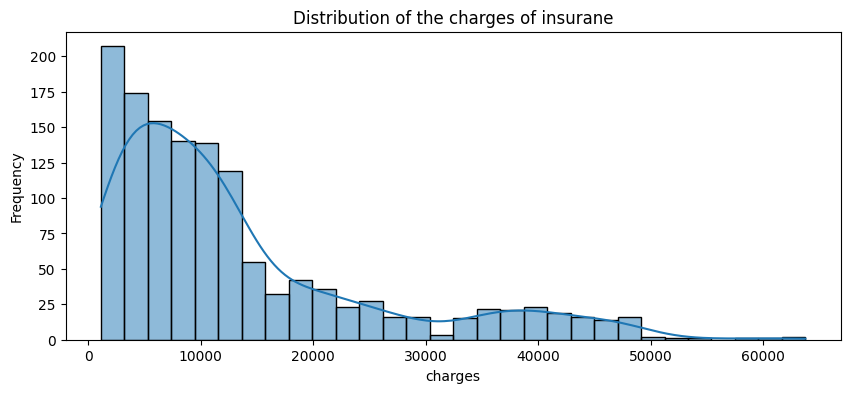

In [37]:
#univariate analysis on the columns
#histogram of the column "amount"
plt.figure(figsize=(10, 4))
sns.histplot(isr["charges"], bins = 30, kde = True)
plt.title("Distribution of the charges of insurane")
plt.xlabel("charges")
plt.ylabel("Frequency")
plt.show();

In [38]:
#from the graph above, we have more people that paid insurance of 0 to 10000. Although, the graph is skewed to the right.

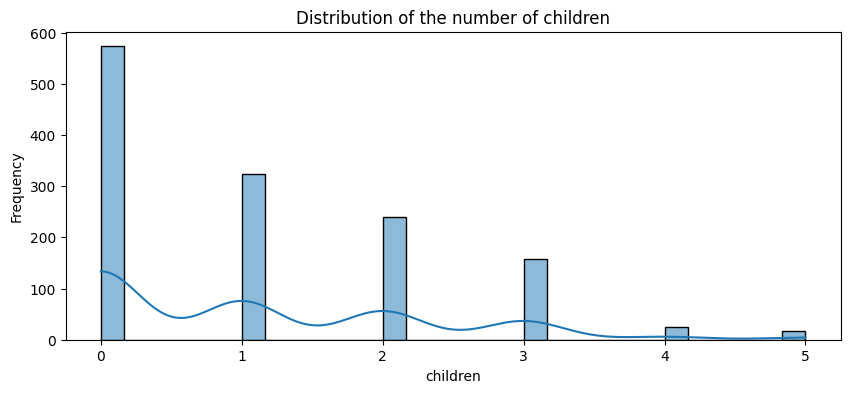

In [39]:
#histogram of the column "amount"
plt.figure(figsize=(10, 4))
sns.histplot(isr["children"], bins = 30, kde = True)
plt.title("Distribution of the number of children")
plt.xlabel("children")
plt.ylabel("Frequency")
plt.show();

In [40]:
#the chart above shows that we have 0 to be the highest number of children. this actually means there are a lot of
#individulas or patients that do not have children.
#so, this means that the higher the number of children, the higher the charge of the insurance.

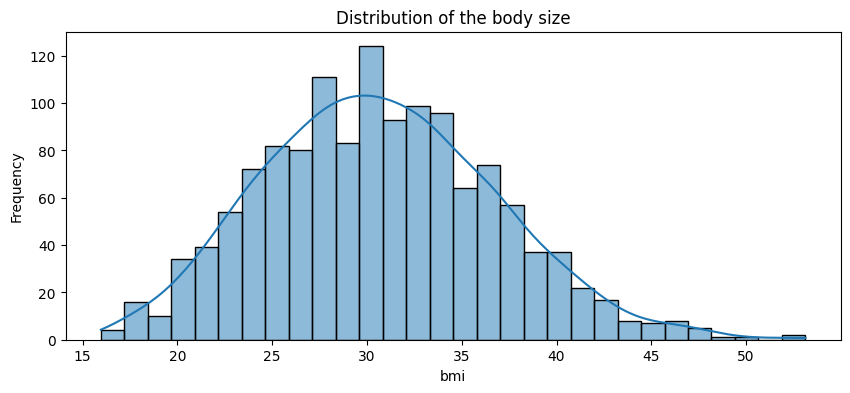

In [41]:
#histogram of the column "amount"
plt.figure(figsize=(10, 4))
sns.histplot(isr["bmi"], bins = 30, kde = True)
plt.title("Distribution of the body size")
plt.xlabel("bmi")
plt.ylabel("Frequency")
plt.show();

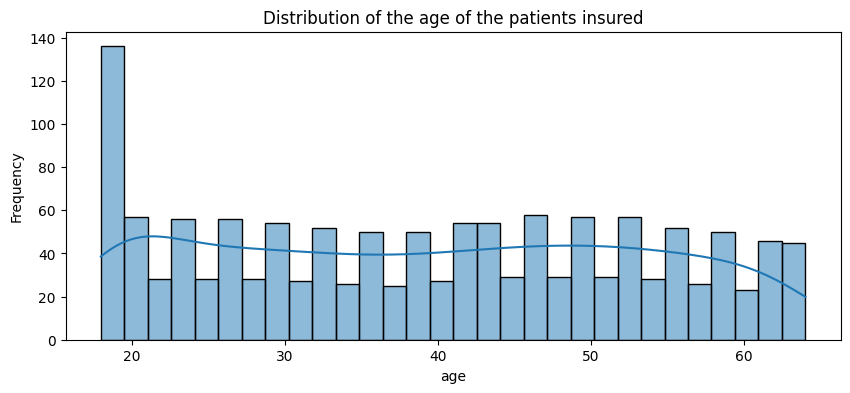

In [42]:
#histogram of the column "amount"
plt.figure(figsize=(10, 4))
sns.histplot(isr["age"], bins = 30, kde = True)
plt.title("Distribution of the age of the patients insured")
plt.xlabel("age")
plt.ylabel("Frequency")
plt.show();

In [43]:
cat

Index(['sex', 'smoker', 'region', 'body_range'], dtype='object')

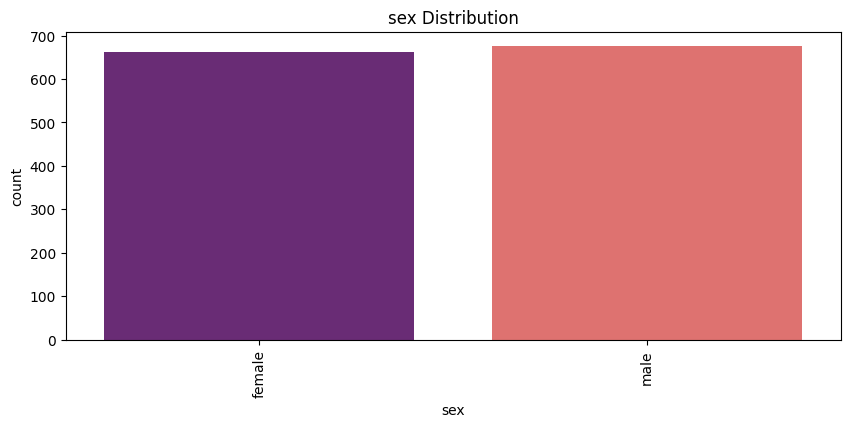

In [44]:
#category column -> distribution
plt.figure(figsize=(10,4))
sns.countplot(x = "sex", data = isr, palette = "magma")
plt.title("sex Distribution")
plt.xlabel("sex")
plt.ylabel("count")
plt.xticks(rotation = 90)
plt.show();

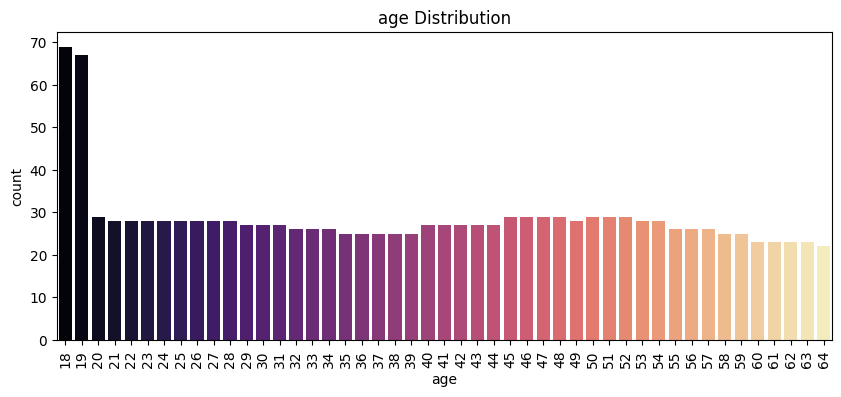

In [80]:
#category column -> distribution
plt.figure(figsize=(10,4))
sns.countplot(x = "age", data = isr, palette = "magma")
plt.title("age Distribution")
plt.xlabel("age")
plt.ylabel("count")
plt.xticks(rotation = 90)
plt.show();

In [ ]:
#this shows that young people have the highest record of medical insurance.

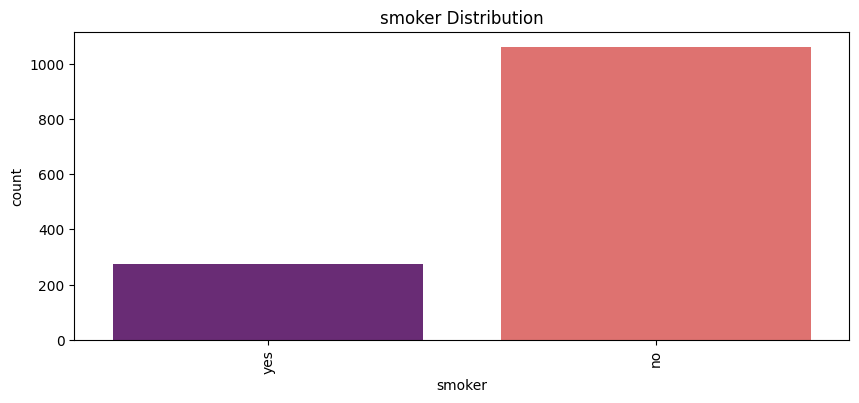

In [45]:
#category column -> distribution
plt.figure(figsize=(10,4))
sns.countplot(x = "smoker", data = isr, palette = "magma")
plt.title("smoker Distribution")
plt.xlabel("smoker")
plt.ylabel("count")
plt.xticks(rotation = 90)
plt.show();

In [46]:
#this shows that a lot of people that do not smoke are really insured.

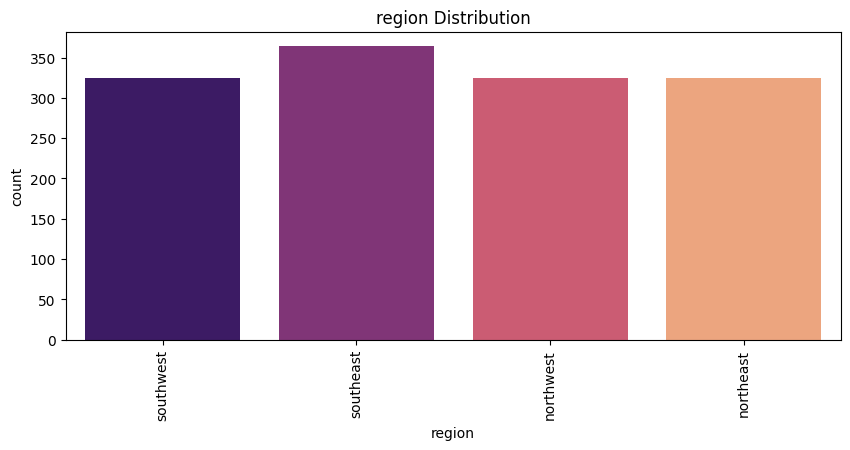

In [47]:
##category column -> distribution
plt.figure(figsize=(10,4))
sns.countplot(x = "region", data = isr, palette = "magma")
plt.title("region Distribution")
plt.xlabel("region")
plt.ylabel("count")
plt.xticks(rotation = 90)
plt.show();

In [48]:
#this shows that many people from the southeast region people actually pay for insurance than the other regions.

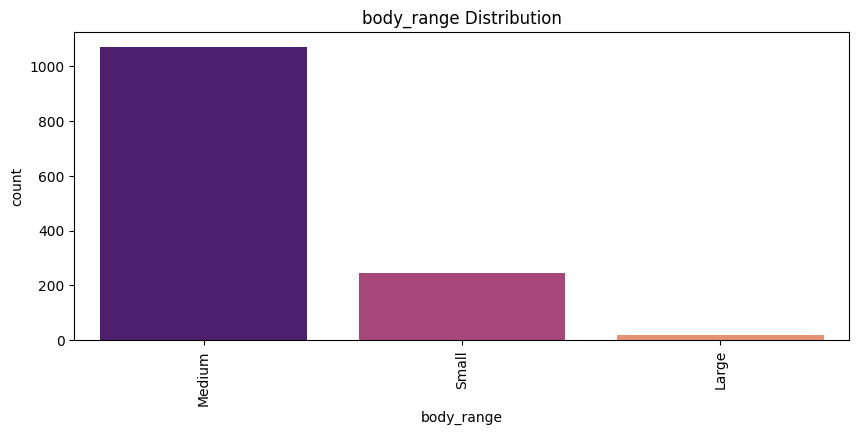

In [49]:
#category column -> distribution
plt.figure(figsize=(10,4))
sns.countplot(x = "body_range", data = isr, palette = "magma")
plt.title("body_range Distribution")
plt.xlabel("body_range")
plt.ylabel("count")
plt.xticks(rotation = 90)
plt.show();

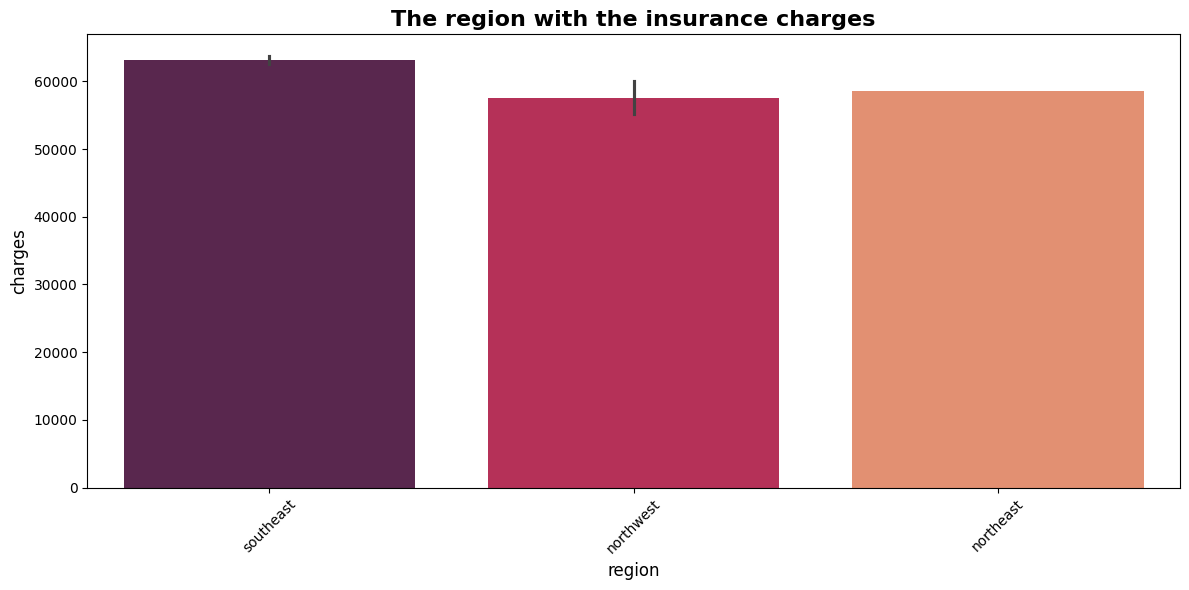

In [94]:
#bivariate analysis
#Seaborn
top_region = isr.sort_values('charges', ascending = False).head()

plt.figure(figsize =(12,6))
sns.barplot(data =top_region,
            x ='region',
            y ='charges',
            palette = 'rocket'
            )
plt.title('The region with the insurance charges', fontsize=16, fontweight='bold')
plt.xlabel('region', fontsize=12)
plt.ylabel('charges', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

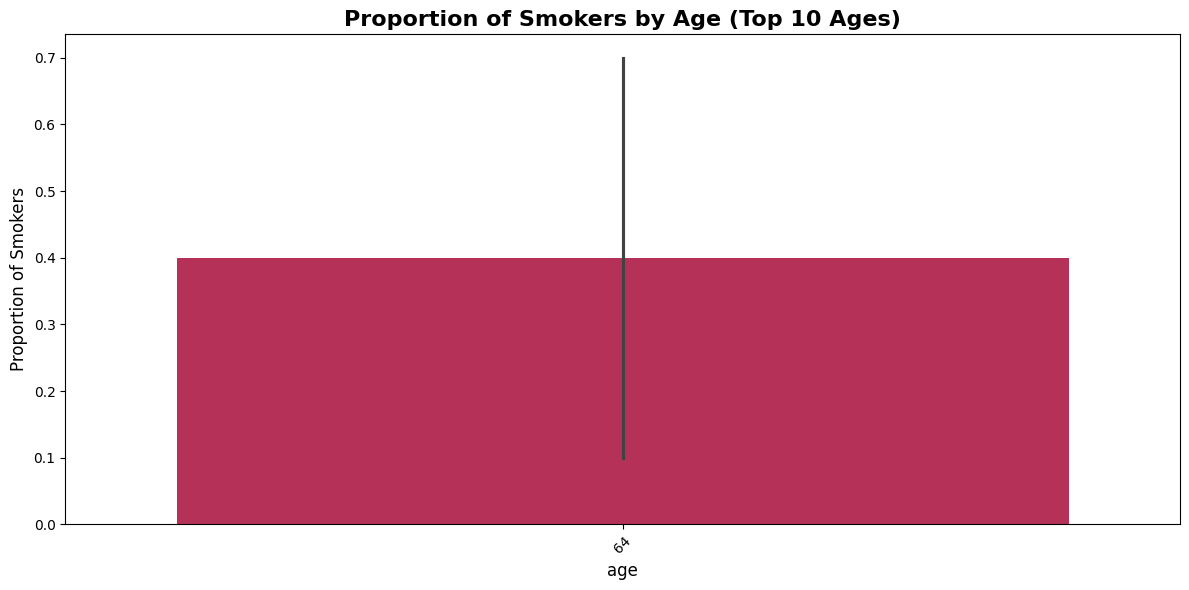

In [96]:
age_smokers = isr.sort_values('age', ascending = False).head(10)

# Encode 'smoker' column to numerical values (0 for 'no', 1 for 'yes')
# This allows sns.barplot to calculate the proportion of smokers for each age
age_smokers_encoded = age_smokers.copy()
age_smokers_encoded['smoker_numeric'] = age_smokers_encoded['smoker'].apply(lambda x: 1 if x == 'yes' else 0)

plt.figure(figsize =(12,6))
sns.barplot(data = age_smokers_encoded,
            x ='age',
            y ='smoker_numeric',
            palette = 'rocket'
            )
plt.title('Proportion of Smokers by Age (Top 10 Ages)', fontsize=16, fontweight='bold')
plt.xlabel('age', fontsize=12)
plt.ylabel('Proportion of Smokers', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [85]:
isr.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'body_range'],
      dtype='object')

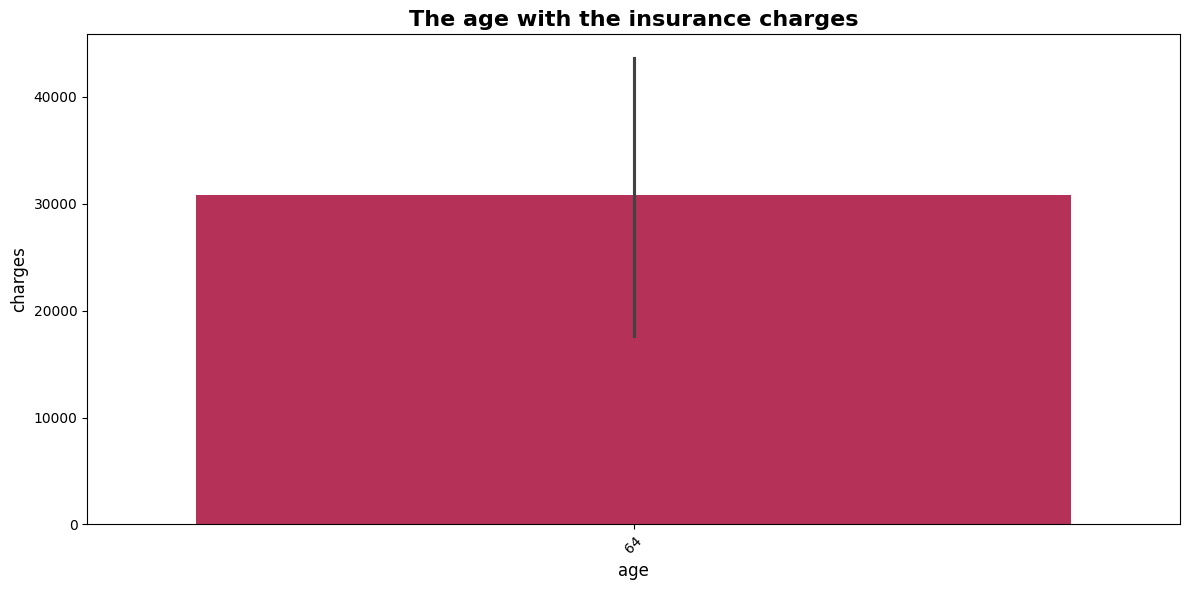

In [79]:
age = isr.sort_values('age', ascending = False).head()

plt.figure(figsize =(12,6))
sns.barplot(data = age,
            x ='age',
            y ='charges',
            palette = 'rocket'
            )
plt.title('The age with the insurance charges', fontsize=16, fontweight='bold')
plt.xlabel('age', fontsize=12)
plt.ylabel('charges', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:
#this shows that old people pay high amount of charges of medical insurance but they are few.

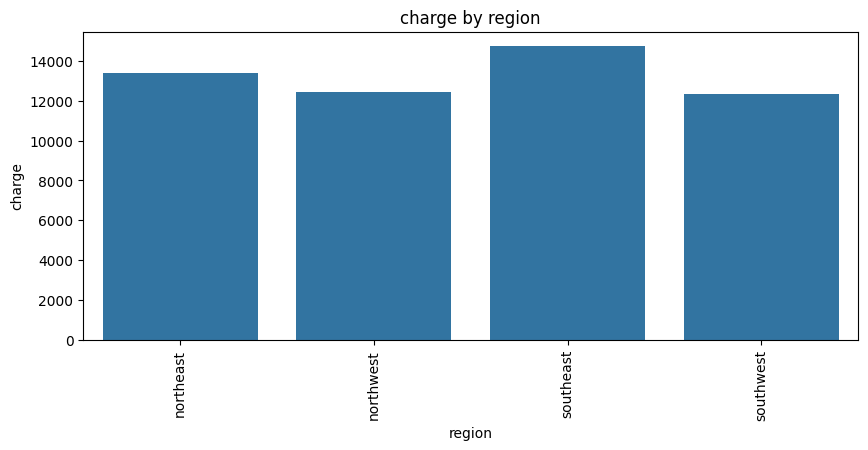

In [88]:
#region by charges
region_charge = isr.groupby("region")["charges"].mean()
plt.figure(figsize=(10,4))
sns.barplot(x = region_charge.index, y = region_charge.values)
plt.title("charge by region")
plt.xlabel("region")
plt.ylabel("charge")
plt.xticks(rotation = 90)
plt.show();

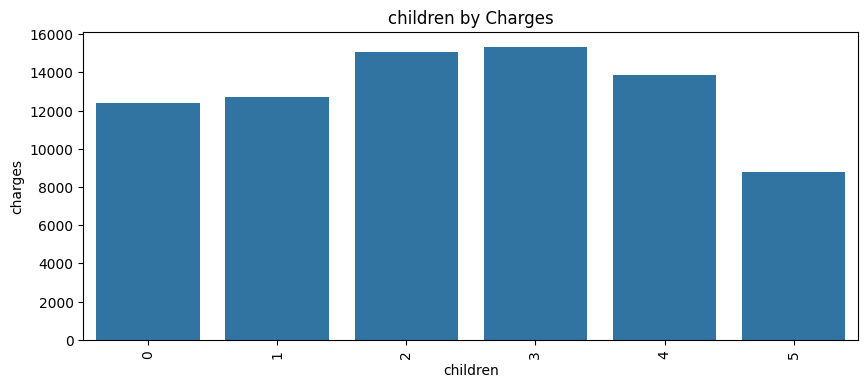

In [53]:
#children by charges
cat_amount = isr.groupby("children")["charges"].mean()
plt.figure(figsize = (10,4))
sns.barplot(x = cat_amount.index, y = cat_amount.values)
plt.title("children by Charges")
plt.xlabel("children")
plt.ylabel("charges")
plt.xticks(rotation = 90)
plt.show();

In [54]:
#this shows that people with three children pay hihger charges than people witrh other children count

In [55]:
isr["children"].value_counts()

,count
children,
0,573
1,324
2,240
3,157
4,25
5,18


In [56]:
#IQR-based outliers for amount column
def find_iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)]

outliers_charges = find_iqr_outliers(isr['charges'].dropna())
print("IQR-based outliers in charges(count):", outliers_charges.shape[0])
display(outliers_charges.tail())

IQR-based outliers in charges(count): 139


,charges
1300,62592
1301,46718
1303,37829
1313,36397
1323,43896


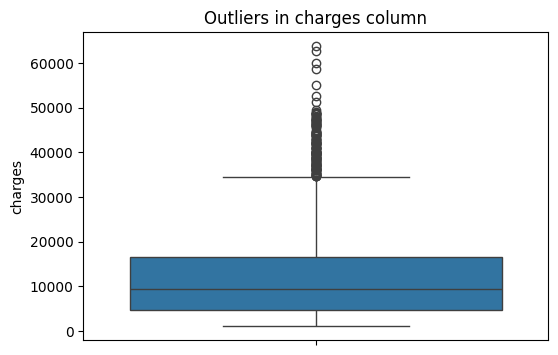

In [57]:
plt.figure(figsize=(6,4))
sns.boxplot(isr["charges"])
plt.title("Outliers in charges column")
plt.show()

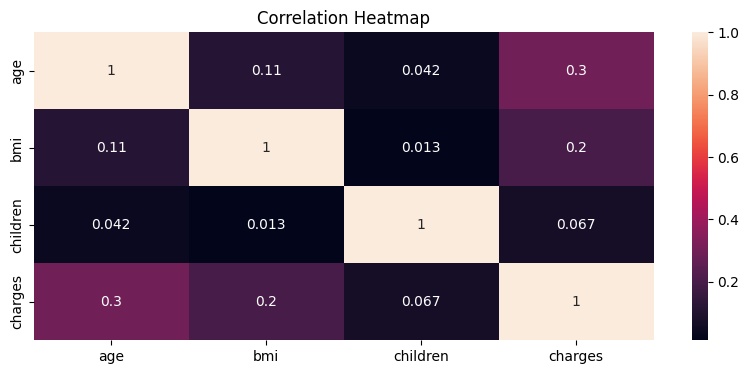

In [58]:
plt.figure(figsize = (10,4))
sns.heatmap(isr.corr(numeric_only = True), annot = True)
plt.title("Correlation Heatmap")
plt.show();

In [59]:
#libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error #metrics to evaluate our models performance

In [60]:
isr.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'body_range'],
      dtype='object')

In [61]:
#defining X and y
y = isr["charges"] #target variable
X = isr.drop(columns = ["charges"], axis = 1) #features

In [62]:
X.head()

,age,sex,bmi,children,smoker,region,body_range
0,19,female,27.900,0,yes,southwest,Medium
1,18,male,33.770,1,no,southeast,Medium
2,28,male,33.000,3,no,southeast,Medium
3,33,male,22.705,0,no,northwest,Small
4,32,male,28.880,0,no,northwest,Medium


In [63]:
categorical_features = X.select_dtypes(include=["object"]).columns
numerical_features = X.select_dtypes(include = ["float64", "int64"]).columns

categorical_features

Index(['sex', 'smoker', 'region', 'body_range'], dtype='object')

In [64]:
numerical_features

Index(['age', 'bmi', 'children'], dtype='object')

In [65]:
#scaling
scale = StandardScaler()
encoder = OneHotEncoder(handle_unknown = "ignore")


#column transformer
preprocessor = ColumnTransformer(
    transformers = [
        ("num", scale, numerical_features),
        ("cat", encoder, categorical_features)
    ]
)

In [66]:
#Train-Test Split
#split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1069, 7), (268, 7), (1069,), (268,))

In [67]:
#defining the models
models = {
    "Linear Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("rf_regressor", RandomForestRegressor(random_state = 42))
    ])
}

In [68]:
models

{'Linear Regression': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num', StandardScaler(),
                                                   Index(['age', 'bmi', 'children'], dtype='object')),
                                                  ('cat',
                                                   OneHotEncoder(handle_unknown='ignore'),
                                                   Index(['sex', 'smoker', 'region', 'body_range'], dtype='object'))])),
                 ('regressor', LinearRegression())]),
 'Random Forest': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num', StandardScaler(),
                                                   Index(['age', 'bmi', 'children'], dtype='object')),
                                                  ('cat',
                                                   OneHotEncoder(handle_unknown='ignore'),
                                                   Index(['sex'

In [98]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
  """
  Evaluate the model on the training and test dataset

  Return:
      The performance of the model: RMSE, MAE, R2 Score

  """

  #train the model
  model.fit(X_train, y_train)

  #make predictions by testing the model with our x test partition
  y_preds = model.predict(X_test)

  #evalute performance
  mae = mean_absolute_error(y_test, y_preds)
  rmse = np.sqrt(mean_squared_error(y_test, y_preds))
  r2 = r2_score(y_test, y_preds)

  return mae, rmse, r2

In [107]:
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds

array([10075.28,  6978.9 , 11729.09, 42433.02,  6053.15,  9721.74,
       39009.11,  2210.96,  8747.98, 11047.83, 13854.91, 24325.51,
       42415.67, 15345.78,  7259.41,  9029.71, 10350.48, 39616.64,
        4612.83,  5107.01,  9193.38, 20893.35,  9632.7 , 20577.21,
       38354.86, 17318.12, 42535.01, 45948.58, 11244.17, 13394.87,
        4234.92,  9097.79,  2838.61, 14320.07, 47334.89,  9729.81,
        7617.59,  5499.32, 22863.95,  8821.58,  2901.15, 21212.18,
       41820.76,  9691.95,  9153.38,  3670.68,  2975.36,  7949.41,
        5494.79, 14348.89,  5012.49,  8466.4 , 22328.21,  6283.72,
        7231.83,  8884.21, 11191.96,  5322.34, 40785.18,  7249.93,
       10802.25,  5404.91, 17169.23,  1748.61, 13583.17, 14387.4 ,
        7651.57, 23472.88, 16930.76, 16853.3 , 11874.51, 15772.55,
        7952.13,  7544.36, 10975.98,  3939.59, 14433.29,  5809.21,
       10630.75, 12806.  ,  9803.64, 17126.93, 13910.19,  9476.7 ,
       28467.7 , 15377.39,  3384.36,  2348.08,  6889.74,  3740

In [99]:
#training each model

results = []  #used to store the model's result

for model_name, model in models.items():
  #using the function to evaluate each model in the dictionary
  mae, rmse, r2 = evaluate_model(model, X_train, X_test, y_train, y_test)

  #getting the results
  results.append({
      "Model": model_name,
      "MAE": mae,
      "RMSE": rmse,
      "R2_Score": r2
  })

#creating a dataframe for the results

results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,R2_Score
0,Linear Regression,4247.565687,6086.264851,0.798414
1,Random Forest,2568.959590,4668.244180,0.881405


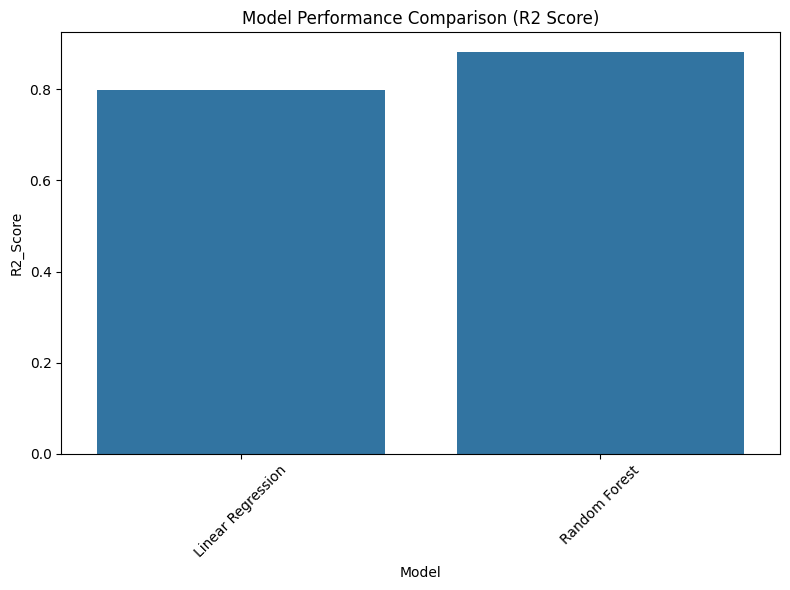

In [100]:
#Visual Comparison of Model Performance

plt.figure(figsize=(8, 6))
sns.barplot(data = results_df, x = "Model", y = "R2_Score")
plt.title("Model Performance Comparison (R2 Score)")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show();

In [109]:
#get features names after preprocessing
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

# Initialize coefficients or feature importances based on the model type
if "rf_regressor" in model.named_steps: # This is the Random Forest model
    # For Random Forest, we get feature importances
    coefficients = model.named_steps["rf_regressor"].feature_importances_
    metric_name = "Feature Importance"
elif "regressor" in model.named_steps: # This is the Linear Regression model
    # For Linear Regression, we get coefficients
    coefficients = model.named_steps["regressor"].coef_
    metric_name = "Coefficient"
else:
    raise ValueError("Unknown regressor type in the pipeline.")

#create a dataframe
coef_df = pd.DataFrame({
    "Feature": feature_names,
    metric_name: coefficients
}).sort_values(by = metric_name, ascending = False)


#get the top 10
print(f"Top 10 {metric_name}s for the {model_name} model:")
coef_df.head(10)

Top 10 Feature Importances for the Random Forest model:


,Feature,Feature Importance
5,cat__smoker_no,0.325325
6,cat__smoker_yes,0.275451
1,num__bmi,0.209550
0,num__age,0.135235
2,num__children,0.022813
8,cat__region_northwest,0.005500
9,cat__region_southeast,0.005219
7,cat__region_northeast,0.004730
4,cat__sex_male,0.004700
3,cat__sex_female,0.003832


In [102]:
coefficients

array([1.35235225e-01, 2.09549886e-01, 2.28128046e-02, 3.83198997e-03,
       4.70047404e-03, 3.25325070e-01, 2.75450869e-01, 4.72964368e-03,
       5.50046612e-03, 5.21947541e-03, 3.78214306e-03, 1.24431810e-04,
       1.81912488e-03, 1.91839654e-03])

In [103]:
from sklearn.model_selection import cross_val_score

#cross validation
cv_scores = cross_val_score(models["Random Forest"],
                            X,
                            y,
                            scoring = "neg_root_mean_squared_error", cv = 5)

print(f"Average CV RMSE: {-cv_scores.mean()}")

Average CV RMSE: 4815.2573722242505
